In [10]:
!pip install mysql-connector-python

In [11]:
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Step 1 : Connecting to MySQL Database
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Shikher@07", 
    database="bank_churn" 
)

In [13]:
# Step 2: Writing relational SQL query to assemble the analytical dataset
query = """
SELECT 
    c.customer_id, c.age, c.gender, c.country,
    a.credit_card, a.active_member, a.products_number, a.estimated_salary,
    f.credit_score, f.balance, f.tenure, f.churn,
    f.account_creation_date, f.exit_date
FROM Fact_Churn f
JOIN Dim_Customer c ON f.customer_id = c.customer_id
JOIN Dim_Account a ON f.customer_id = a.customer_id;
"""

In [14]:
# 3. Load into a Pandas DataFrame
df = pd.read_sql(query, conn)
conn.close()

print(f"Successfully pulled {df.shape[0]} rows and {df.shape[1]} columns from MySQL!")
print(df.head())

Successfully pulled 10000 rows and 14 columns from MySQL!
   customer_id  age  gender  country  credit_card  active_member  \
0     15565701   39  Female    Spain            0              0   
1     15565706   35    Male    Spain            1              1   
2     15565714   47    Male   France            0              1   
3     15565779   30  Female  Germany            1              0   
4     15565796   48    Male  Germany            1              0   

   products_number  estimated_salary  credit_score    balance  tenure  churn  \
0                1          90212.38           698  161993.89       9      0   
1                1          83256.26           612       0.00       1      1   
2                2          96517.97           601   64430.06       1      0   
3                1         188258.49           627   57809.32       6      0   
4                1          74510.65           745   96048.55      10      0   

  account_creation_date exit_date  
0               

C:\Users\sahil\AppData\Local\Temp\ipykernel_20364\3179687025.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [ ]:
# Calculate Churn Rate by Country and Gender
geo_gender_churn = df.groupby(['country', 'gender'])['churn'].mean() * 100
print("--- Churn Rate (%) by Geography and Gender ---")
print(geo_gender_churn)

--- Churn Rate (%) by Geography and Gender ---
country  gender
France   Female    20.344980
         Male      12.713404
Germany  Female    37.552389
         Male      27.811550
Spain    Female    21.212121
         Male      13.112392
Name: churn, dtype: float64


In [ ]:
#Looking at churn rates above we can say: france and spain are relatively stable however Germany has 98% higher churn rate. 
#This reveals a local failure instead of an global one.
#Also Female have 50%-60% higher churn rates than males.

In [16]:
# Calculate Churn Rate based on number of bank products held
product_churn = df.groupby('products_number')['churn'].mean() * 100
print("\n--- Churn Rate (%) by Number of Products Held ---")
print(product_churn)


--- Churn Rate (%) by Number of Products Held ---
products_number
1     27.714398
2      7.581699
3     82.706767
4    100.000000
Name: churn, dtype: float64


In [ ]:
# customers with one or two products have standard churn rates
# However as soon as they have 3 or more products churn rate increase exponentially
# This indicates either high hidden fees or lack of management of mulitple bank products

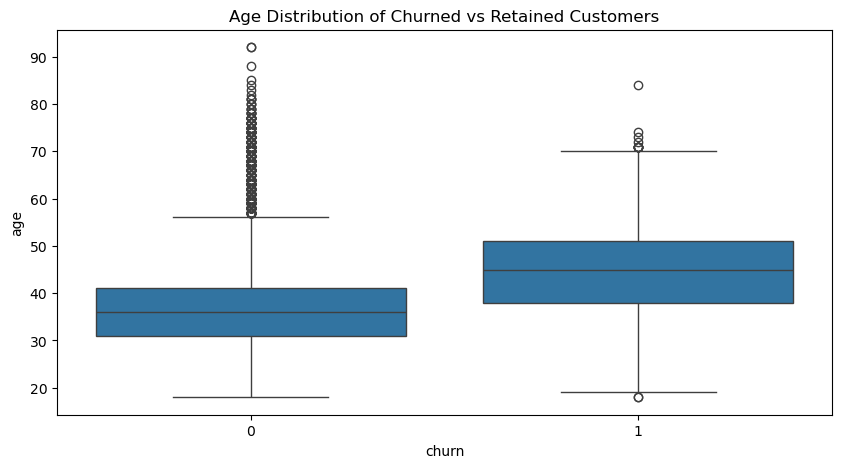

In [17]:
# Visualize relationship between Balance, Age, and Churn
plt.figure(figsize=(10, 5))
sns.boxplot(x='churn', y='age', data=df)
plt.title('Age Distribution of Churned vs Retained Customers')
plt.show()

In [ ]:
#Older, established customers—who typically hold the highest balances and mortgages—are abandoning the bank.
#We are keeping the young, low-balance students and losing the profitable demographic.